## Problem Statement

The objective of this project is to predict supplier risk using supplier quality, financial, operational, and communication metrics. The model helps identify high-risk suppliers to support proactive supply chain decision-making.

## Data Loading


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\DELL\Downloads\supplier_quality.csv")

print(df.head())
print(df.info())
print(df.describe())

   supplier_id region  distance_km  financial_score  years_active  \
0            1   APAC      3522.24             65.1             4   
1            1   APAC      3522.24             65.1             4   
2            1   APAC      3522.24             65.1             4   
3            1   APAC      3522.24             65.1             4   
4            1   APAC      3522.24             65.1             4   

   lead_time_days  on_time_delivery  delay_days  lot_size  unit_price  \
0           30.96                 1        0.00       655        4.52   
1           36.31                 1        0.00       947        4.62   
2           33.45                 1        0.00       964        4.34   
3           30.77                 0        7.41       924        4.91   
4           27.94                 1        0.00      1241        4.92   

   price_variance  defect_rate  defects  communication_score  \
0           0.070        0.015       12                65.17   
1           0.002 

## Data Cleaning

In [3]:
print(df.isnull().sum())

supplier_id               0
region                    0
distance_km               0
financial_score           0
years_active              0
lead_time_days            0
on_time_delivery          0
delay_days                0
lot_size                  0
unit_price                0
price_variance            0
defect_rate               0
defects                   0
communication_score       0
certifications         2779
inspection_skip           0
supplier_risk             0
dtype: int64


In [5]:
df["certifications"] = df["certifications"].fillna("Unknown")

## Exploratory Data Analysis

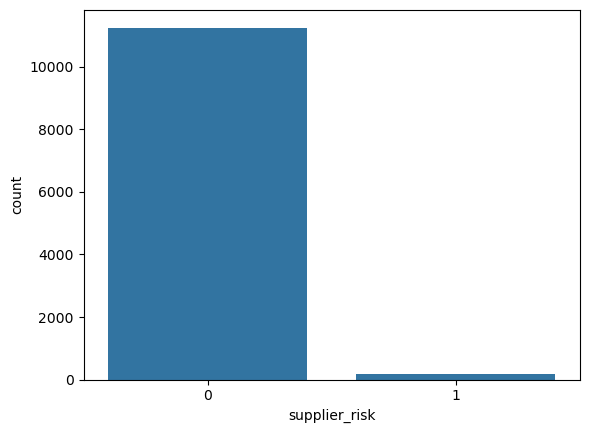

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="supplier_risk", data=df)
plt.show()

In [7]:
df.groupby("supplier_risk")["financial_score"].mean()

supplier_risk
0    69.024320
1    47.690874
Name: financial_score, dtype: float64

In [8]:
df.groupby("supplier_risk")["defect_rate"].mean()

supplier_risk
0    0.018584
1    0.025426
Name: defect_rate, dtype: float64

In [9]:
df.groupby("supplier_risk")["on_time_delivery"].mean()

supplier_risk
0    0.869233
1    0.000000
Name: on_time_delivery, dtype: float64

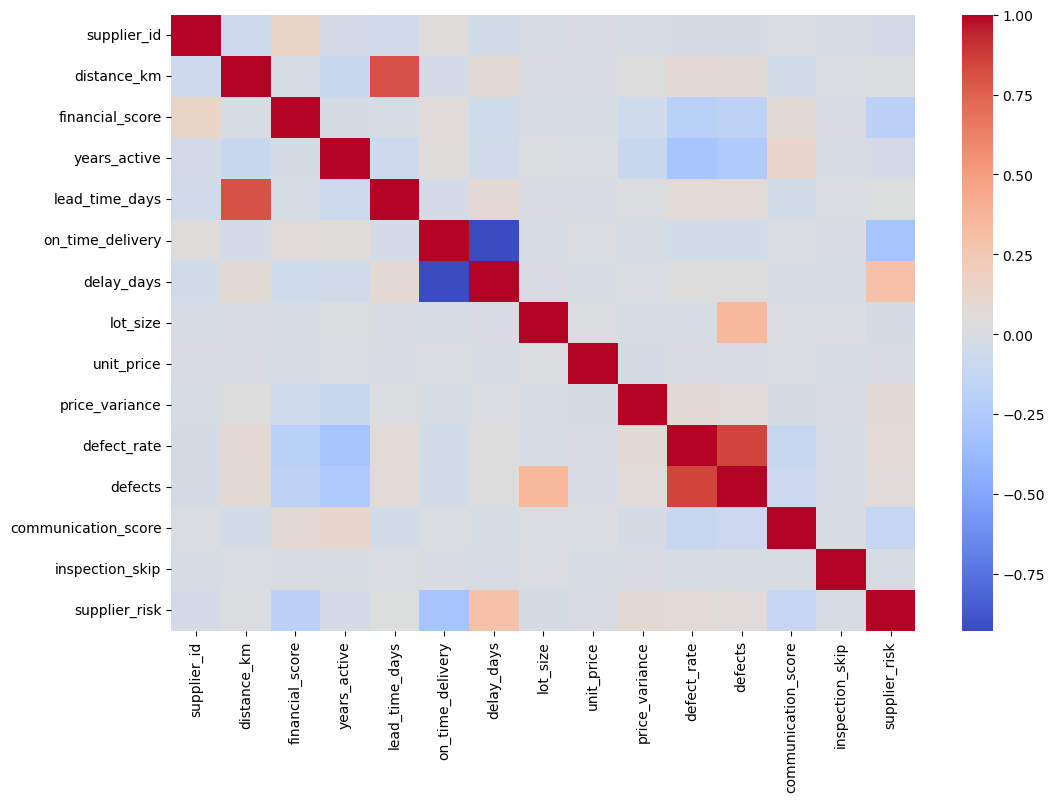

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    cmap="coolwarm"
)

plt.show()

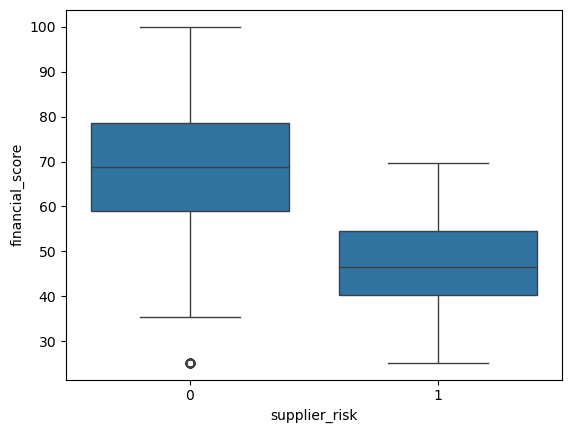

In [11]:
sns.boxplot(
    x="supplier_risk",
    y="financial_score",
    data=df
)

plt.show()

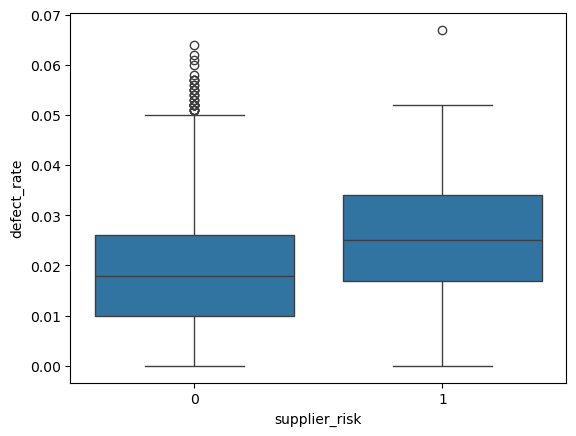

In [12]:
sns.boxplot(
    x="supplier_risk",
    y="defect_rate",
    data=df
)

plt.show()

In [13]:
X = df.drop("supplier_risk", axis=1)
y = df["supplier_risk"]

In [14]:
X = df.drop(["supplier_risk", "supplier_id"], axis=1)

## Feature Engineering

In [15]:
X = pd.get_dummies(
    X,
    columns=["region", "certifications"],
    drop_first=True
)

## Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Standardization

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Handling Class Imbalance (SMOTE)

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [23]:
print(y_train_smote.value_counts())

supplier_risk
0    8999
1    8999
Name: count, dtype: int64


## Logistic Regression Model


In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [25]:
y_pred = model.predict(X_test)

## Model Evaluation

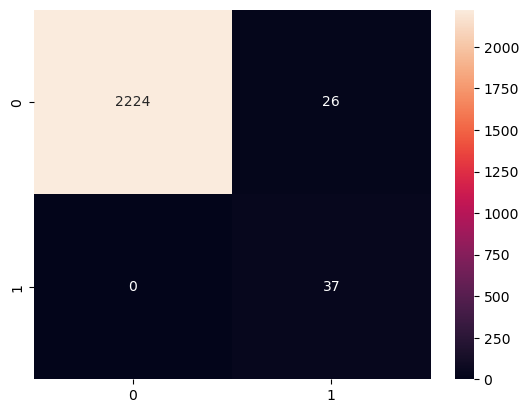

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

In [27]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2250
           1       0.59      1.00      0.74        37

    accuracy                           0.99      2287
   macro avg       0.79      0.99      0.87      2287
weighted avg       0.99      0.99      0.99      2287



## Feature Importance

In [28]:
import numpy as np

feature_names = X.columns

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients.head(10))

                            Feature  Coefficient
8                    price_variance     3.005551
10                          defects     0.764035
0                       distance_km     0.520401
5                        delay_days     0.164572
9                       defect_rate     0.112368
16           certifications_Unknown     0.038279
15  certifications_ISO9001+ISO14001    -0.036945
2                      years_active    -0.057888
3                    lead_time_days    -0.075492
7                        unit_price    -0.136508


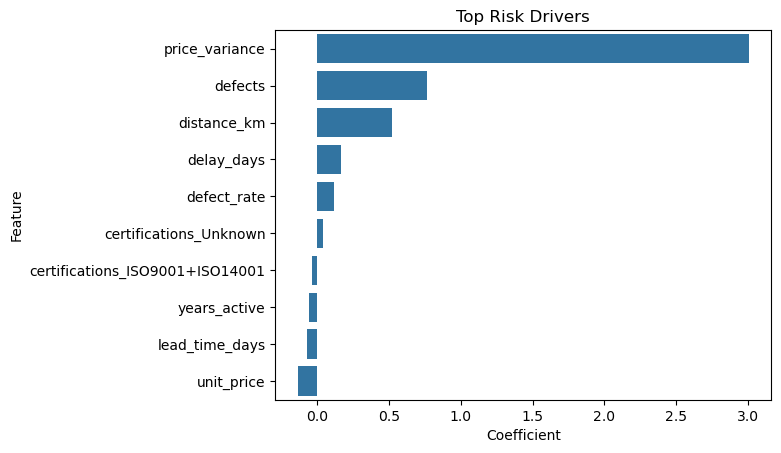

In [29]:
top_features = coefficients.head(10)

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=top_features
)

plt.title("Top Risk Drivers")
plt.show()

## Conclusion

- Logistic Regression achieved excellent predictive performance.
- Defect rate and delivery delays were among the strongest indicators of supplier risk.
- The model can support supplier evaluation and early risk identification.